In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
plt.style.use('ggplot')

In [5]:
class Linear_Regression:
    def __init__(self, X, T, degree):
        
        self.T = T
        self.X = X
        self.degree = degree
    
    def design_matrix(self):
        self.Phi = np.vander(self.X, N = self.degree + 1, increasing = True)
        return self.Phi

    def ML(self):
        Phi = self.Phi
        T = self.T
        self.w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ T
        return self.w

    def fit(self):
        self.design_matrix()
        return self.ML()
    
    def evaluate(self):
        T = self.T
        Phi = self.Phi
        w = self.w
        return Phi @ w - T

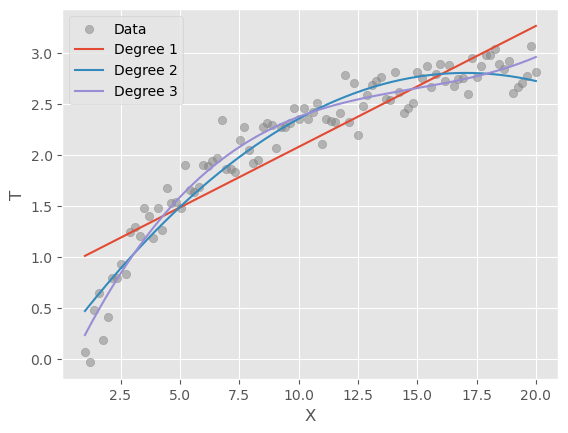

In [16]:
#Plotting with simple dataset

rng = np.random.default_rng(42)
X = np.linspace(1, 20, 100)
T = np.log(X) + rng.normal(0, 0.2, size=X.size)

x_grid = np.linspace(X.min(), X.max(), 200)

plt.scatter(X, T, color='grey', alpha=0.5, label='Data')

for degree in [1, 2, 3]:
    model = Linear_Regression(X, T, degree)
    w = model.fit()

    Phi_grid = np.vander(x_grid, N=degree + 1, increasing=True)
    plt.plot(x_grid, Phi_grid @ w, label=f'Degree {degree}')

plt.xlabel('X')
plt.ylabel('T')
plt.legend()
plt.show()